# Imports Overview

This code imports the libraries needed for building and training a deep learning model on the CIFAR-10 dataset.

## What each import is for

- `os`: Handles operating system related tasks such as file paths and environment settings.
- `random`: Used for random number generation and reproducibility utilities.
- `numpy as np`: Provides numerical operations and array handling.
- `matplotlib.pyplot as plt`: Used for plotting graphs and visualizing results.

- `tensorflow as tf`: Main deep learning framework.
- `Sequential, Input`: Used to define a neural network model.
- `Dense, Conv2D, MaxPooling2D, Dropout, Flatten`: Common layers for building CNNs.
- `cifar10`: Built-in CIFAR-10 dataset loader.
- `to_categorical`: Converts class labels into one-hot encoded format.

- `MultipleLocator, FormatStrFormatter`: Help customize axis ticks and number formatting in plots.
- `dataclass`: Used to create simple structured classes for storing configuration or parameters.

## Purpose

These imports prepare the environment for:
- loading and preprocessing CIFAR-10 data,
- building a convolutional neural network,
- training and evaluating the model,
- and visualizing the results.


In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from dataclasses import dataclass


## Reproducibility: Setting Random Seeds

This code block sets a fixed random seed to ensure reproducible results across different runs of the script.

- `SEED_VALUE = 42`: Defines a constant seed value used for all random number generators.
- `random.seed(SEED_VALUE)`: Sets the seed for Python’s built-in `random` module, affecting functions like `random.random`, `random.shuffle`, etc.
- `np.random.seed(SEED_VALUE)`: Sets the seed for NumPy’s global random number generator, ensuring deterministic behavior for NumPy-based randomness.
- `tf.random.set_seed(SEED_VALUE)`: Sets TensorFlow’s random seed so that operations like weight initialization, shuffling, and dropout behave deterministically (as far as TensorFlow allows).

By using the same `SEED_VALUE` across these libraries, experiments can be repeated with consistent results.


In [6]:
SEED_VALUE = 42  # Define a fixed seed value for reproducibility

random.seed(SEED_VALUE)        # Set the seed for Python's built-in random module
np.random.seed(SEED_VALUE)     # Set the seed for NumPy's random number generator
tf.random.set_seed(SEED_VALUE) # Set the seed for TensorFlow's random operations


## Loading the CIFAR-10 Dataset

This code block loads the CIFAR-10 dataset and prints the shapes of the training and test image arrays.

- `cifar10.load_data()`: Loads the CIFAR-10 dataset, which is already split into training and test sets.
- `X_train, y_train`: Contain the training images and their corresponding labels.
- `X_test, y_test`: Contain the test images and their corresponding labels.

After loading the data:
- `print(X_train.shape)` displays the shape of the training image set.
- `print(X_test.shape)` displays the shape of the test image set.

For CIFAR-10, the image data typically has the following shapes:
- Training set: `(50000, 32, 32, 3)`
- Test set: `(10000, 32, 32, 3)`

This means:
- `50000` training images and `10000` test images
- each image has a size of `32 × 32`
- and `3` color channels (RGB)


In [8]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()  # Load the CIFAR-10 dataset and split it into training and test sets

print(X_train.shape)  # Print the shape of the training images array
print(X_test.shape)   # Print the shape of the test images array


(50000, 32, 32, 3)
(10000, 32, 32, 3)


## Visualizing Sample Images from the Training Set

This code displays a grid of images from the CIFAR-10 training dataset.

### What it does
- `plt.figure(figsize=(18, 9))`: Creates a large figure for displaying multiple images clearly.
- `num_rows = 4` and `num_cols = 8`: Define the layout of the image grid.
- `for i in range(num_rows * num_cols)`: Loops through the first 32 training images.
- `plt.subplot(...)`: Places each image into its position inside the grid.
- `plt.imshow(X_train[i, :, :])`: Displays the `i`-th image.
- `plt.axis("off")`: Hides axis markings for a cleaner visualization.
- `plt.show()`: Renders the final plot.

### Purpose
This is useful for quickly inspecting the dataset and understanding what the CIFAR-10 images look like.


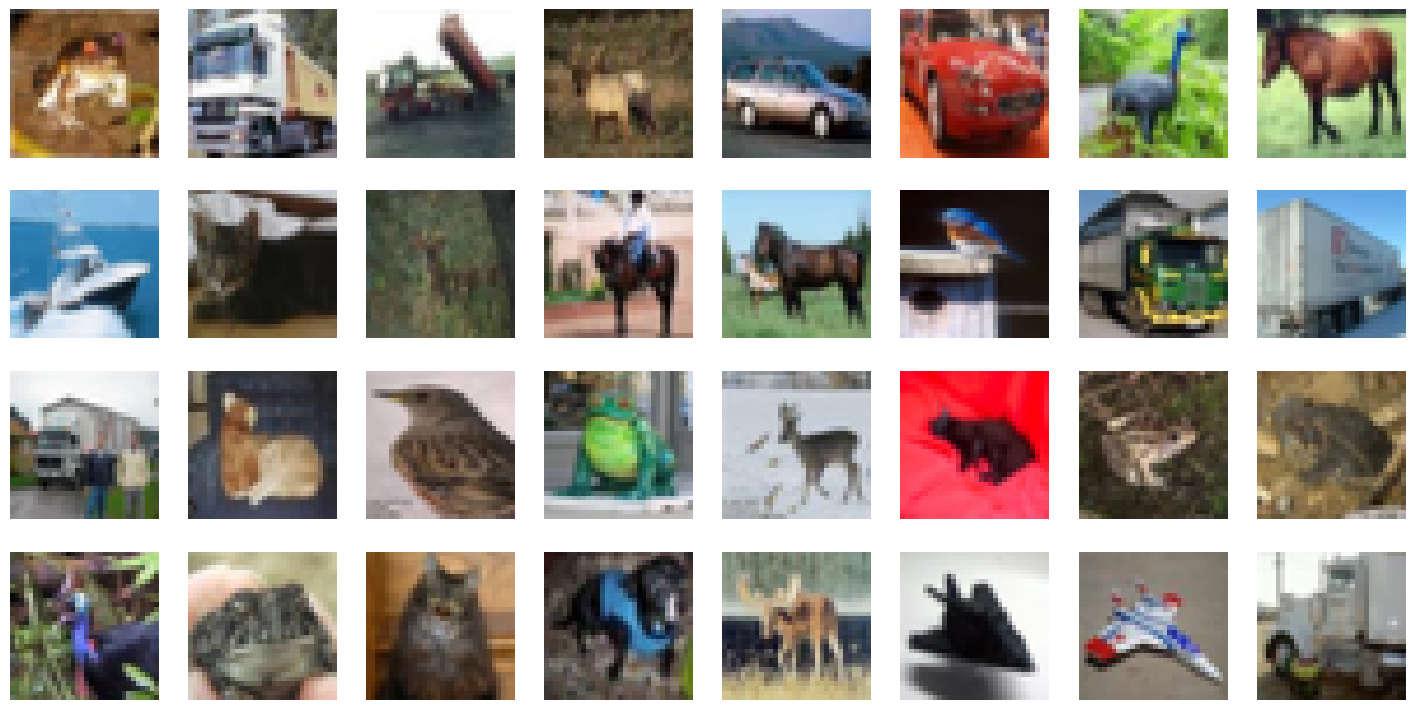

In [10]:
plt.figure(figsize=(18, 9))  # Create a figure with a wide layout for displaying multiple images

num_rows = 4  # Set the number of rows in the image grid
num_cols = 8  # Set the number of columns in the image grid

for i in range(num_rows * num_cols):  # Loop through the first 32 images
    ax = plt.subplot(num_rows, num_cols, i + 1)  # Create a subplot for the current image
    plt.imshow(X_train[i, :, :])  # Display the i-th training image
    plt.axis("off")  # Hide axis ticks and labels for a cleaner view

plt.show()  # Show the complete figure


## Data Preprocessing: Normalization and One-Hot Encoding

This code block performs two essential preprocessing steps on the CIFAR-10 dataset before feeding it to a neural network: scaling pixel values and converting class labels to one-hot encoded vectors.

### 1. Pixel Value Normalization

The original image arrays are typically stored as `uint8` (integers in the range 0–255). They are first cast to `float32` to allow fractional values. Dividing by `255` rescales every pixel into the range `[0.0, 1.0]`. This is important for stable and faster convergence during gradient descent, as smaller input values help the optimizer work more efficiently.

### 2. One-Hot Encoding of Labels

The original labels (`y_train`, `y_test`) are integer class indices (0–9 for CIFAR-10). `to_categorical` converts each integer label into a one-hot vector, e.g., class `6` becomes `[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]`. This format is required when using categorical cross-entropy loss with a softmax output layer.

### Output Verification

The two `print` statements show the label of the first training sample before and after conversion, demonstrating the change from an integer to a one-hot encoded vector.


In [12]:
X_train = X_train.astype("float32") / 255  # Normalize pixel values: convert to float32 and scale from [0, 255] to [0.0, 1.0]
X_test = X_test.astype("float32") / 255     # Apply the same normalization to the test set

print('Original (integer) label for the first training sample: ', y_train[0])  # Display the original integer label of the first training sample

y_train = to_categorical(y_train)  # Convert integer class labels to one-hot encoded categorical format
y_test = to_categorical(y_test)    # Apply the same one-hot encoding to the test labels

print('After conversion to categorical one-hot encoded labels: ', y_train[0])  # Display the one-hot encoded label of the first training sample after conversion


Original (integer) label for the first training sample:  [6]
After conversion to categorical one-hot encoded labels:  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## Configuration Classes for Dataset and Training

This code defines two frozen dataclasses that store constant configuration values for the dataset and training process.

### `DatasetConfig`
This class keeps the main properties of the CIFAR-10 dataset:
- number of classes
- image height
- image width
- number of color channels

### `TrainingConfig`
This class stores the training hyperparameters:
- number of epochs
- batch size
- learning rate

### Why this is useful
Using dataclasses for configuration makes the code:
- cleaner and easier to read
- easier to maintain
- less likely to contain accidental changes, because `frozen=True` makes the values immutable


In [14]:
# Stores fixed configuration values for the dataset
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 10
    IMG_HEIGHT: int = 32
    IMG_WIDTH: int = 32
    NUM_CHANNELS: int = 3


# Stores fixed hyperparameters for training
@dataclass(frozen=True)
class TrainingConfig:
    EPOCHS: int = 31
    BATCH_SIZE: int = 256
    LEARNING_RATE: float = 0.001


## CNN Model Definition

This function builds a convolutional neural network (CNN) for image classification on the CIFAR-10 dataset.

### Model structure
- An `Input` layer receives images with shape `(32, 32, 3)`.
- The network contains **three convolutional blocks**:
  - first block: 32 filters
  - second block: 64 filters
  - third block: 64 filters
- Each block uses:
  - `Conv2D` layers with `relu` activation
  - `MaxPooling2D` for downsampling
- After feature extraction:
  - `Flatten()` converts feature maps into a 1D vector
  - `Dense(512, activation='relu')` adds a fully connected hidden layer
  - `Dense(10, activation='softmax')` produces class probabilities for the 10 CIFAR-10 classes

### Purpose
This architecture is designed to learn spatial patterns from images and classify them into one of the 10 categories.


In [18]:
def cnn_model(input_shape=(32, 32, 3)):
    model = Sequential()
    
    model.add(Input(shape=input_shape))
    
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model


## Model Instantiation and Summary

This code block instantiates the previously defined CNN model and displays its architecture.

### What it does
- `model = cnn_model()`: Calls the `cnn_model` function to create an instance of the Keras `Sequential` model.
- `model.summary()`: Prints a detailed table showing the model's layers, output shapes, and the number of trainable and non-trainable parameters.

### Purpose
The summary is essential for:
- **Verifying the architecture**: Ensuring that layers are connected correctly and output shapes match expectations.
- **Parameter count**: Checking the complexity of the model (total weights and biases) to ensure it is appropriate for the dataset and hardware.


In [19]:
model = cnn_model() # Create an instance of the CNN model
model.summary()     # Print the model architecture summary to the console


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,354 (2.55 MB)

 Trainable params: 669,354 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation

This step configures the model for training by specifying the optimizer, loss function, and evaluation metrics.

### Configuration Details

- **Optimizer (`rmsprop`)**: Root Mean Square Propagation is an adaptive learning rate optimizer. It is particularly effective for training deep neural networks as it adjusts the learning rate for each parameter individually based on recent gradients.
- **Loss Function (`categorical_crossentropy`)**: This is the standard loss function for multi-class classification tasks where labels are one-hot encoded. It measures the dissimilarity between the predicted probability distribution and the actual distribution.
- **Metrics (`accuracy`)**: This tells Keras to monitor the classification accuracy (the percentage of correctly predicted images) during both training and validation.

### Purpose
Compiling the model is mandatory before calling the `fit` method. It defines how the model should learn from the data and how its performance should be measured.


In [20]:
model.compile(optimizer='rmsprop',              # Set the optimizer to RMSprop for adaptive weight updates
              loss='categorical_crossentropy',  # Use Categorical Crossentropy for multi-class classification loss
              metrics=['accuracy'],             # Track accuracy as the primary performance metric
             )


## Model Training

This code trains the CNN model on the CIFAR-10 training set.

### What it does
- `model.fit(...)` starts the training process.
- `X_train` and `y_train` are the input images and their corresponding labels.
- `batch_size=TrainingConfig.BATCH_SIZE` sets how many samples are processed before each weight update.
- `epochs=TrainingConfig.EPOCHS` specifies how many full passes over the training data are performed.
- `verbose=1` enables progress output during training.
- `validation_split=.3` reserves 30% of the training data for validation.

### Output
The training history is stored in the variable `history`, which can later be used to plot training and validation loss/accuracy curves.


In [21]:
history = model.fit(X_train,  # Training images
                    y_train,  # Training labels
                    batch_size=TrainingConfig.BATCH_SIZE,  # Number of samples per gradient update
                    epochs=TrainingConfig.EPOCHS,  # Number of full training passes over the dataset
                    verbose=1,  # Show training progress
                    validation_split=.3,  # Reserve 30% of the training data for validation
                   )


Epoch 1/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 46s 305ms/step - accuracy: 0.2399 - loss: 2.0782 - val_accuracy: 0.3121 - val_loss: 1.8135
Epoch 2/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 41s 302ms/step - accuracy: 0.3892 - loss: 1.6848 - val_accuracy: 0.4381 - val_loss: 1.5293
Epoch 3/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 305ms/step - accuracy: 0.4710 - loss: 1.4640 - val_accuracy: 0.4533 - val_loss: 1.5051
Epoch 4/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 83s 309ms/step - accuracy: 0.5311 - loss: 1.3097 - val_accuracy: 0.5037 - val_loss: 1.4009
Epoch 5/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 52s 383ms/step - accuracy: 0.5813 - loss: 1.1780 - val_accuracy: 0.5687 - val_loss: 1.1989
Epoch 6/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 43s 310ms/step - accuracy: 0.6247 - loss: 1.0634 - val_accuracy: 0.5400 - val_loss: 1.2897
Epoch 7/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 304ms/step - accuracy: 0.6609 - loss: 0.9628 - val_accuracy: 0.6263 - val_loss: 1.0506
Epoch 8/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 300ms/step - accuracy: 0.7019 - loss: 0

## Plotting Training Results

This function plots one or more training metrics across epochs.

### What it does
- Creates a figure with a fixed size.
- Accepts either a single metric or a list/tuple of metrics.
- Plots each metric with the corresponding color.
- Labels the x-axis as `Epoch` and sets the y-axis label dynamically.
- Applies limits to the x-axis and y-axis.
- Configures major and minor tick spacing on the x-axis.
- Adds a grid and legend.
- Displays and closes the plot.

### Purpose
This function is useful for visualizing model performance such as training loss, validation loss, training accuracy, and validation accuracy over time.


In [23]:
def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None):
    
    fig, ax = plt.subplots(figsize=(15, 4))  # Create a figure and axis with a wide layout

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):  # Check whether metric_name is a single value or a collection
        metrics = [metrics]  # Wrap a single metric into a list
        metric_name = [metric_name]  # Wrap the metric name into a list

    for idx, metric in enumerate(metrics):  # Iterate over all provided metrics
        ax.plot(metric, color=color[idx])  # Plot each metric using the corresponding color

    plt.xlabel("Epoch")  # Label the x-axis as Epoch
    plt.ylabel(ylabel)  # Set the y-axis label
    plt.title(title)  # Set the plot title
    plt.xlim([0, TrainingConfig.EPOCHS - 1])  # Limit the x-axis to the training epoch range
    plt.ylim(ylim)  # Set the y-axis limits

    ax.xaxis.set_major_locator(MultipleLocator(5))  # Set major ticks every 5 epochs
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))  # Format major tick labels as integers
    ax.xaxis.set_minor_locator(MultipleLocator(1))  # Set minor ticks every 1 epoch

    plt.grid(True)  # Enable grid lines
    plt.legend(metric_name)  # Display the legend for the plotted metrics
    plt.show()  # Show the plot
    plt.close()  # Close the figure to free resources


## Plotting Training and Validation Curves

This code block extracts the training history data and uses the `plot_results` function to visualize the loss and accuracy over the training epochs.

### Data Extraction
- `history.history[...]` provides a dictionary containing the recorded values for the specified metrics during training.
- `train_loss`, `train_acc`: Loss and accuracy measured on the training data.
- `valid_loss`, `valid_acc`: Loss and accuracy measured on the validation split.

### Loss Visualization
The first `plot_results` call visualizes:
- **Training Loss** (in green) and **Validation Loss** (in blue).
- The y-axis is limited to `[0.0, 5.0]` for clarity.

### Accuracy Visualization
The second `plot_results` call visualizes:
- **Training Accuracy** (in green) and **Validation Accuracy** (in blue).
- The y-axis is limited to `[0.0, 1.0]` (representing 0% to 100% accuracy).

### Purpose
Visualizing these curves helps diagnose potential issues like overfitting (validation loss rising while training loss continues to fall) or underfitting.


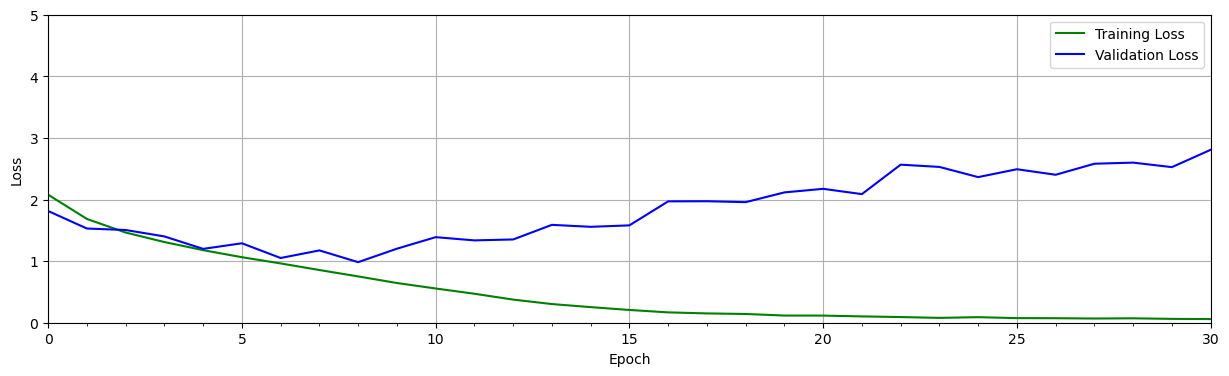

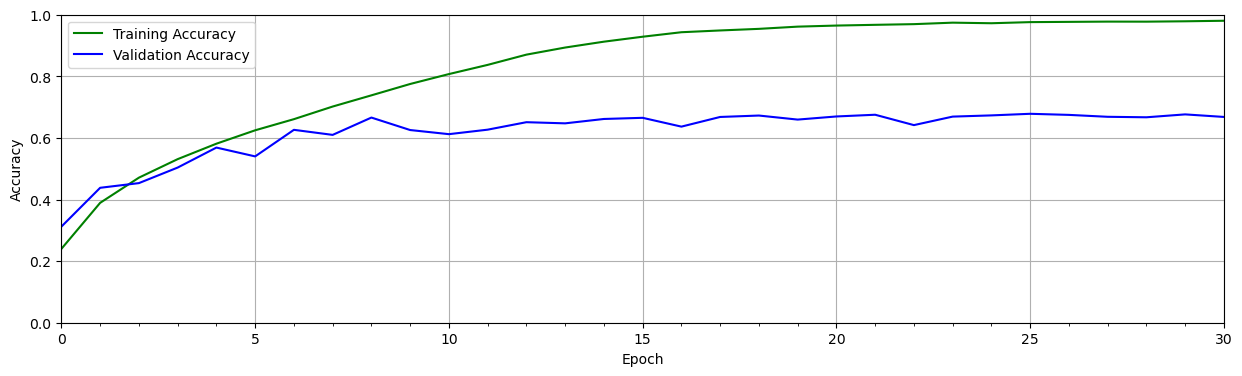

In [24]:
train_loss = history.history["loss"]        # Extract training loss values from the history object
train_acc = history.history["accuracy"]    # Extract training accuracy values
valid_loss = history.history["val_loss"]  # Extract validation loss values
valid_acc = history.history["val_accuracy"] # Extract validation accuracy values

# Plotting the loss curves (Training Loss vs. Validation Loss)
plot_results(
    [train_loss, valid_loss],
    ylabel="Loss",
    ylim=[0.0, 5.0],
    metric_name=["Training Loss", "Validation Loss"],
    color=["g", "b"]
)

# Plotting the accuracy curves (Training Accuracy vs. Validation Accuracy)
plot_results(
    [train_acc, valid_acc],
    ylabel="Accuracy",
    ylim=[0.0, 1.0],
    metric_name=["Training Accuracy", "Validation Accuracy"],
    color=["g", "b"]
)


## CNN Model with Dropout Regularization

This function defines a Convolutional Neural Network (CNN) architecture similar to the previous one, but with the addition of **Dropout** layers to prevent overfitting.

### Model Architecture
- **Convolutional Blocks**: Three blocks, each consisting of two `Conv2D` layers with ReLU activation followed by a `MaxPooling2D` layer.
- **Dropout Layers**: 
    - After each max-pooling step, a `Dropout(0.25)` layer is added, which randomly sets 25% of the activations to zero during training.
    - Before the final output layer, a `Dropout(0.5)` layer is applied to the 512-unit dense layer to further regularize the model.
- **Output Layer**: A `Dense` layer with 10 units and a `softmax` activation function for multi-class classification.

### Purpose of Dropout
Dropout is a regularization technique that helps the model generalize better to unseen data by forcing it to learn redundant representations and preventing it from becoming overly dependent on specific neurons.


In [26]:
def cnn_model_dropout(input_shape=(32, 32, 3)):

    model = Sequential()  # Initialize a sequential model

    # First Block
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))  # First conv layer
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))  # Second conv layer
    model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling to reduce spatial dimensions
    model.add(Dropout(0.25))  # Dropout to reduce overfitting

    # Second Block
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))  # Third conv layer
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))  # Fourth conv layer
    model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling
    model.add(Dropout(0.25))  # Dropout

    # Third Block
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))  # Fifth conv layer
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))  # Sixth conv layer
    model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling
    model.add(Dropout(0.25))  # Dropout

    # Classification Head
    model.add(Flatten())  # Flatten 3D feature maps into a 1D vector
    model.add(Dense(512, activation='relu'))  # Fully connected layer with 512 neurons
    model.add(Dropout(0.5))  # Higher dropout rate for the dense layer
    model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes

    return model  # Return the regularized model


## Creating and Inspecting the Dropout CNN Model

This code block creates an instance of the CNN model with dropout regularization and prints its architecture summary.

### What it does
- `model_dropout = cnn_model_dropout()`: Calls the `cnn_model_dropout` function and creates the dropout-based CNN model.
- `model_dropout.summary()`: Displays a layer-by-layer summary of the model, including:
  - layer names
  - output shapes
  - number of parameters

### Purpose
This step is useful for verifying that:
- the model has been built correctly,
- dropout layers are included in the expected positions,
- and the total number of trainable parameters matches the intended architecture.


In [27]:
model_dropout = cnn_model_dropout()  # Create an instance of the CNN model with dropout regularization
model_dropout.summary()  # Print the architecture summary of the dropout-based CNN model


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,354 (2.55 MB)

 Trainable params: 669,354 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Dropout CNN Model

This code compiles the `model_dropout` by configuring its training parameters: the optimizer, loss function, and evaluation metrics.

### Configuration Details
- **Optimizer**: `rmsprop` (Root Mean Square Propagation) is chosen again. This adaptive learning rate optimizer is suitable for this model.
- **Loss Function**: `categorical_crossentropy` is used, which is appropriate for multi-class classification with one-hot encoded labels.
- **Metrics**: `accuracy` is selected to monitor the model's performance during training and evaluation.

### Purpose
Compiling the model is a necessary step before training. It prepares the model by defining how it will learn from the data and how its performance will be evaluated. This setup is identical to the previous model's compilation, ensuring a fair comparison of the effects of dropout.


In [30]:
model_dropout.compile(
    optimizer='rmsprop',               # Set the optimizer to RMSprop
    loss='categorical_crossentropy',   # Use categorical crossentropy for multi-class classification
    metrics=['accuracy']               # Track accuracy during training and evaluation
)


## Training the Dropout CNN Model

This code trains the `model_dropout` (the CNN with dropout regularization) on the CIFAR-10 dataset.

### Training Parameters
- **Data**: It uses the preprocessed `X_train` (images) and `y_train` (one-hot encoded labels).
- **Batch Size**: `TrainingConfig.BATCH_SIZE` (which is 256) is used, meaning 256 samples are processed in each training step.
- **Epochs**: `TrainingConfig.EPOCHS` (which is 31) determines the number of full passes over the training dataset.
- **Verbose**: `verbose=1` displays a progress bar and metrics for each epoch.
- **Validation Split**: `validation_split=0.3` sets aside 30% of the training data to evaluate the model's performance on unseen data after each epoch. This is crucial for monitoring overfitting.

### Output
The training process's history (metrics like loss and accuracy for both training and validation sets) is stored in the `history` variable. This history can be used later to plot performance curves and analyze the training progress.


In [46]:
history = model_dropout.fit(
    X_train,  # Training data (images)
    y_train,  # Training data (labels)
    batch_size=TrainingConfig.BATCH_SIZE,  # Number of samples per gradient update
    epochs=TrainingConfig.EPOCHS,  # Number of epochs to train for
    verbose=1,  # Set verbosity mode (1 = progress bar)
    validation_split=0.3  # Fraction of the training data to be used for validation
)


Epoch 1/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 46s 318ms/step - accuracy: 0.2233 - loss: 2.1233 - val_accuracy: 0.3071 - val_loss: 1.9109
Epoch 2/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 314ms/step - accuracy: 0.3381 - loss: 1.8256 - val_accuracy: 0.3758 - val_loss: 1.7499
Epoch 3/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 317ms/step - accuracy: 0.4102 - loss: 1.6277 - val_accuracy: 0.4446 - val_loss: 1.5314
Epoch 4/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 81s 313ms/step - accuracy: 0.4602 - loss: 1.4935 - val_accuracy: 0.4927 - val_loss: 1.4248
Epoch 5/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 310ms/step - accuracy: 0.4991 - loss: 1.3905 - val_accuracy: 0.5256 - val_loss: 1.3418
Epoch 6/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 309ms/step - accuracy: 0.5340 - loss: 1.2969 - val_accuracy: 0.5362 - val_loss: 1.3144
Epoch 7/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 311ms/step - accuracy: 0.5682 - loss: 1.2053 - val_accuracy: 0.5833 - val_loss: 1.1607
Epoch 8/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 308ms/step - accuracy: 0.5938 - loss: 1

## Visualizing Training Results for Dropout Model

This code extracts the training history of the dropout-enabled CNN and uses the `plot_results` function to generate plots for loss and accuracy.

### Data Extraction
- `train_loss`, `train_acc`: Training loss and accuracy recorded during the training process.
- `valid_loss`, `valid_acc`: Validation loss and accuracy, calculated on the held-out 30% of the training data after each epoch.

### Plotting Loss
The first call to `plot_results` displays:
- **Training Loss** (green line)
- **Validation Loss** (blue line)
The y-axis range is set from 0.0 to 5.0 to provide a clear view of the loss trends.

### Plotting Accuracy
The second call to `plot_results` displays:
- **Training Accuracy** (green line)
- **Validation Accuracy** (blue line)
The y-axis range is set from 0.0 to 1.0, representing the accuracy from 0% to 100%.

### Purpose
These plots are used to visually assess the model's learning progress and identify signs of overfitting. Comparing the training and validation curves helps understand how well the model generalizes.


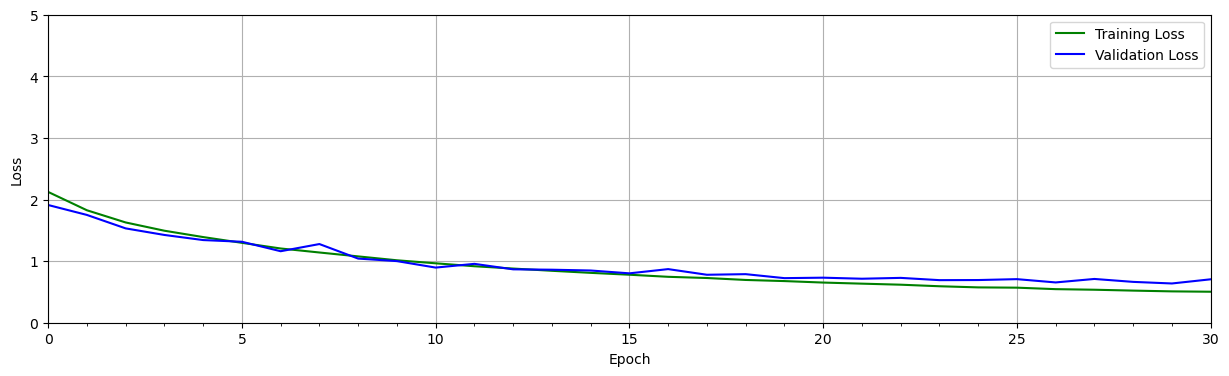

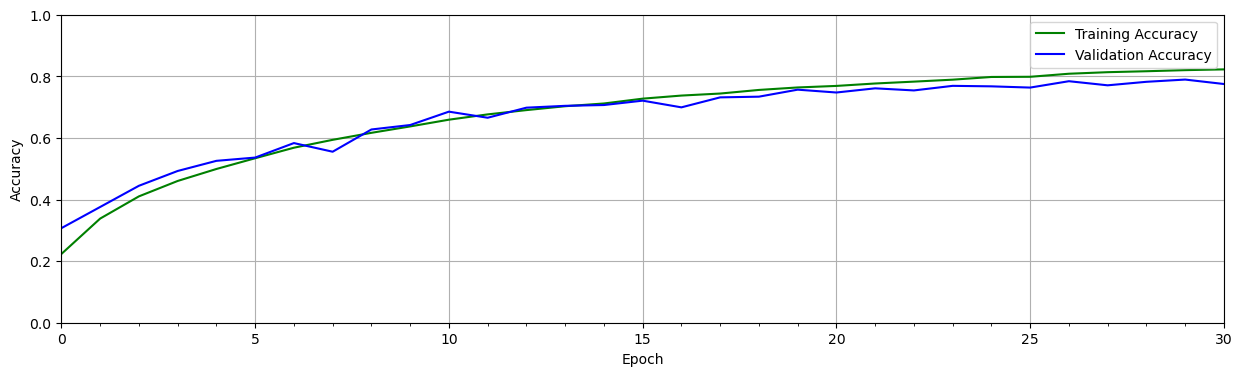

In [47]:
train_loss = history.history["loss"]        # Extract training loss values
train_acc = history.history["accuracy"]    # Extract training accuracy values
valid_loss = history.history["val_loss"]  # Extract validation loss values
valid_acc = history.history["val_accuracy"] # Extract validation accuracy values

# Plotting the training and validation loss curves
plot_results(
    [train_loss, valid_loss],
    ylabel="Loss",
    ylim=[0.0, 5.0],
    metric_name=["Training Loss", "Validation Loss"],
    color=["g", "b"]
)

# Plotting the training and validation accuracy curves
plot_results(
    [train_acc, valid_acc],
    ylabel="Accuracy",
    ylim=[0.0, 1.0],
    metric_name=["Training Accuracy", "Validation Accuracy"],
    color=["g", "b"]
)


## Saving the Trained Model

This command saves the trained `model_dropout` to a file named `model_dropout.keras`.

### What it does
- `model_dropout.save("model_dropout.keras")`: Serializes the model's architecture, weights, and optimizer state into a single file. The `.keras` extension is the recommended format for saving Keras models.

### Purpose
- **Persistence**: Allows you to load and use the trained model later without retraining it.
- **Deployment**: Enables you to deploy the model for inference in various applications.
- **Sharing**: Makes it easy to share your trained model with others.


In [48]:
model_dropout.save("model_dropout.keras")  # Save the trained model architecture and weights to a file


## Loading the Saved Model

This code reloads a previously saved Keras model from a file.

### What it does
- `reloaded_model_dropout = load_model('model_dropout.keras')`: Loads the Keras model architecture, its weights, and the optimizer's state from the specified file (`model_dropout.keras`). The loaded model is assigned to the variable `reloaded_model_dropout`.

### Purpose
This is done to resume training, evaluate the model on new data, or use it for predictions without needing to redefine or retrain the model from scratch. It assumes that `load_model` has been imported from `tensorflow.keras.models`.


In [49]:
reloaded_model_dropout = load_model('model_dropout.keras')  # Load the saved Keras model from the file

## Evaluating the Model on Test Data

This code snippet evaluates the performance of the reloaded Keras model on the test dataset.

### What it does
- `test_loss, test_acc = reloaded_model_dropout.evaluate(X_test, y_test)`: This line uses the `evaluate` method of the Keras model to compute the loss and accuracy of the model on the provided test data (`X_test`, `y_test`). It returns the calculated loss and accuracy.
- `print(f"Test accuracy: {test_acc*100:.3f}")`: This line prints the test accuracy to the console, formatted as a percentage with three decimal places.

### Purpose
The primary purpose is to assess how well the trained model generalizes to unseen data, providing an unbiased measure of its performance.


In [50]:
# Evaluate the reloaded model on the test dataset
# X_test: The features of the test dataset
# y_test: The true labels of the test dataset
test_loss, test_acc = reloaded_model_dropout.evaluate(X_test, y_test)

# Print the test accuracy, formatted as a percentage
print(f"Test accuracy: {test_acc*100:.3f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7659 - loss: 0.7334
Test accuracy: 76.590


## Evaluating Model Predictions and Visualizing Results

This Python function, `evaluate_model`, takes a dataset and a trained model as input. It then visualizes the model's predictions on a sample of the dataset, comparing them against the ground truth labels and highlighting correct and incorrect predictions.

### Function Breakdown:
- `class_names`: A list defining the names of the 10 classes in the CIFAR-10 dataset.
- `num_rows`, `num_cols`: These variables determine the grid dimensions for displaying the images and their predictions.
- `data_batch = dataset[0:num_rows * num_cols]`: Selects a batch of images from the dataset to be used for prediction and visualization.
- `predictions = model.predict(data_batch)`: Uses the provided model to generate predictions for each image in the `data_batch`.
- `plt.figure(figsize=(20, 8))`: Initializes a Matplotlib figure with a specified size to accommodate the image grid.
- `num_matches = 0`: A counter to keep track of the number of correct predictions.
- The `for` loop iterates through each image in the `data_batch`:
    - `ax = plt.subplot(num_rows, num_cols, idx + 1)`: Creates a subplot for each image within the grid.
    - `plt.axis("off")`: Hides the axes for a cleaner image display.
    - `plt.imshow(data_batch[idx])`: Displays the current image.
    - `pred_idx = tf.argmax(predictions[idx]).numpy()`: Determines the index of the class with the highest predicted probability.
    - `truth_idx = tf.argmax(y_test[idx]).numpy()`: Determines the index of the true class label for the current image. **Note:** This line assumes `y_test` is accessible in the scope where this function is defined or called.
    - `title = class_names[truth_idx] + " : " + class_names[pred_idx]`: Constructs a title string showing the true class and the predicted class.
    - `title_obj = plt.title(title, fontdict={'fontsize': 13})`: Sets the title for the subplot.
    - The `if pred_idx == truth_idx:` block checks if the prediction is correct:
        - If correct (`num_matches += 1`), the title color is set to green (`'g'`).
        - If incorrect, the title color is set to red (`'r'`).
- `acc = num_matches / (num_rows * num_cols)`: Calculates the accuracy of the predictions within the displayed batch.
- `print("Prediction accuracy:", round(acc, 2))`: Prints the calculated batch accuracy.
- `plt.show()`: Displays the generated plot with all the subplots, images, and titles.

### Dependencies:
- `tensorflow` (as `tf`) for model prediction and argmax.
- `matplotlib.pyplot` (as `plt`) for plotting.
- `y_test` (numpy array or similar) containing the true labels for the test dataset.
- `dataset` (numpy array or similar) containing the image data.
- `model` (Keras model object) that has a `predict` method.


In [51]:
# Define the function to evaluate and visualize model predictions
def evaluate_model(dataset, model):

    # List of class names for CIFAR-10 dataset
    class_names = [
        'airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck'
    ]

    # Define the number of rows and columns for the subplot grid
    num_rows = 3
    num_cols = 6

    # Select a batch of images from the dataset for evaluation
    # dataset: The dataset containing the images (e.g., X_test)
    data_batch = dataset[0:num_rows * num_cols]

    # Generate predictions for the selected image batch using the provided model
    # model: The trained Keras model
    predictions = model.predict(data_batch)

    # Create a Matplotlib figure for displaying the images and predictions
    # figsize specifies the width and height of the figure in inches
    plt.figure(figsize=(20, 8))
    num_matches = 0 # Initialize a counter for correct predictions

    # Loop through each image in the data batch
    for idx in range(num_rows * num_cols):
        # Create a subplot for each image in the grid
        # (num_rows, num_cols, plot_number)
        ax = plt.subplot(num_rows, num_cols, idx + 1)
        # Turn off the axis display for cleaner visualization
        plt.axis("off")
        # Display the image
        plt.imshow(data_batch[idx])

        # Get the index of the predicted class (highest probability)
        pred_idx = tf.argmax(predictions[idx]).numpy()
        # Get the index of the true class label
        # This assumes y_test is available in the current scope and corresponds to the dataset
        truth_idx = tf.argmax(y_test[idx]).numpy()

        # Construct the title string: "True Class : Predicted Class"
        title = class_names[truth_idx] + " : " + class_names[pred_idx]
        # Set the title for the subplot, specifying font size
        title_obj = plt.title(title, fontdict={'fontsize': 13})

        # Check if the prediction is correct
        if pred_idx == truth_idx:
            num_matches += 1 # Increment the match counter
            # Set the title color to green for correct predictions
            plt.setp(title_obj, color='g')
        else:
            # Set the title color to red for incorrect predictions
            plt.setp(title_obj, color='r')

    # Calculate the accuracy for the displayed batch
    acc = num_matches / (num_rows * num_cols)
    # Print the prediction accuracy for the batch, rounded to 2 decimal places
    print("Prediction accuracy:", round(acc, 2))

    # Display the plot with all images, predictions, and titles
    plt.show()


## Calling the Model Evaluation and Visualization Function

This code snippet invokes the previously defined `evaluate_model` function using the test dataset features and the reloaded dropout model.

### What it does
- `evaluate_model(X_test, reloaded_model_dropout)`: Passes the test dataset features (`X_test`) and the reloaded Keras model (`reloaded_model_dropout`) into the evaluation function. 
- Inside the function, it will select a batch of 18 images (`3` rows $\times$ `6` columns), generate predictions, calculate the batch accuracy, print it, and render a visual grid comparing the true labels against the predicted labels (with green titles for correct predictions and red for incorrect ones).

### Purpose
To visually inspect qualitative performance and compute a quick batch-level accuracy metric using the saved and reloaded model on unseen test data.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Prediction accuracy: 0.72


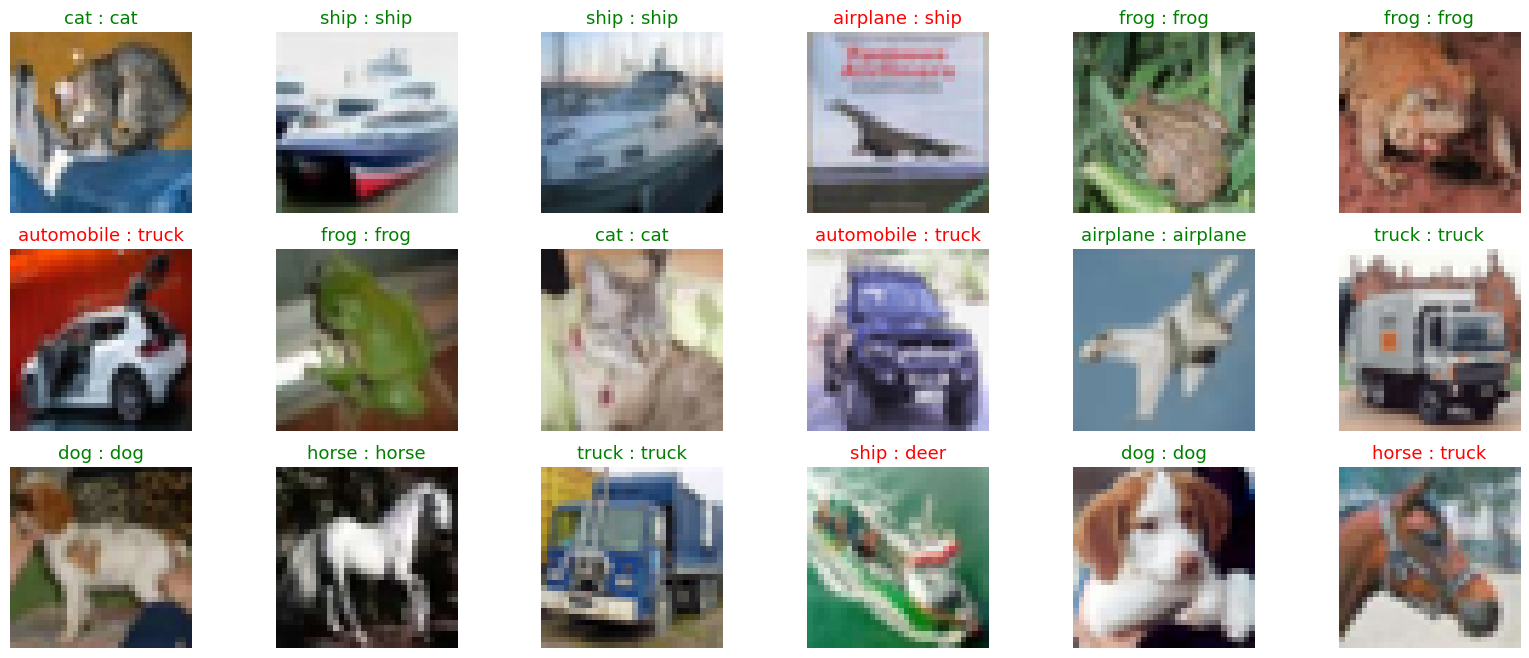

In [52]:
# Call the evaluate_model function using the test dataset and the reloaded model
evaluate_model(X_test, reloaded_model_dropout)  # Evaluate and visualize model predictions on X_test using reloaded_model_dropout


## Generating Predictions and Extracting Labels

This code performs two main actions: first, it generates predictions for the entire test dataset using the reloaded Keras model. Second, it converts these predictions (which are probability distributions over classes) into a list of the most likely class labels for each test sample.

### What it does:
- `predictions = reloaded_model_dropout.predict(X_test)`: This line uses the `predict` method of the loaded Keras model (`reloaded_model_dropout`) to generate probability predictions for each image in the test dataset (`X_test`). The output `predictions` will be a NumPy array where each row corresponds to an image and contains the probabilities for each of the 10 classes.
- `predicted_labels = [np.argmax(i) for i in predictions]`: This is a list comprehension that iterates through each set of predictions for an image (`i` in `predictions`). `np.argmax(i)` finds the index of the class with the highest probability in that prediction set. These indices, representing the predicted class labels, are collected into a new list called `predicted_labels`.

### Purpose:
The goal is to obtain a straightforward list of predicted class labels for the entire test set, which can then be used for further analysis, such as calculating metrics like precision, recall, or generating a confusion matrix.


In [53]:
# Generate predictions for all images in the test dataset
# X_test: The features of the test dataset
predictions = reloaded_model_dropout.predict(X_test)

# Convert the probability predictions to class labels
# For each prediction array (i), find the index of the maximum value (the predicted class)
# This uses a list comprehension for conciseness
predicted_labels = [np.argmax(i) for i in predictions]


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


## Computing and Visualizing the Confusion Matrix

This code calculates a confusion matrix to evaluate the classification performance across all test samples and visualizes it as a heatmap using Seaborn.

### What it does:
- `y_test_integer_labels = tf.argmax(y_test, axis=1)`: Converts one-hot encoded true labels (`y_test`) into 1D integer class label indices by finding the index of the maximum value along `axis=1`.
- `cm = tf.math.confusion_matrix(labels=y_test_integer_labels, predictions=predicted_labels)`: Computes the confusion matrix using TensorFlow, comparing the true integer labels against the predicted integer labels.
- `plt.figure(figsize=(14, 7))`: Creates a matplotlib figure with a specific width and height for the heatmap display.
- `import seaborn as sn`: Imports the Seaborn visualization library (note: typically done at the top of a script, but included locally here).
- `sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size": 12})`: Plots the confusion matrix as a heatmap. `annot=True` writes the data value in each cell, `fmt='d'` formats those values as integers, and `annot_kws` sets the font size of the annotations.
- `plt.title("Confusion Matrix")`: Sets the title of the plot.
- `plt.xlabel("Predicted")`: Labels the x-axis as "Predicted" classes.
- `plt.ylabel("Truth")`: Labels the y-axis as true/actual classes ("Truth").
- `plt.show()`: Renders and displays the complete heatmap.

### Purpose:
To provide a comprehensive breakdown of correct and incorrect predictions for each of the 10 classes, helping identify which classes the model easily confuses.


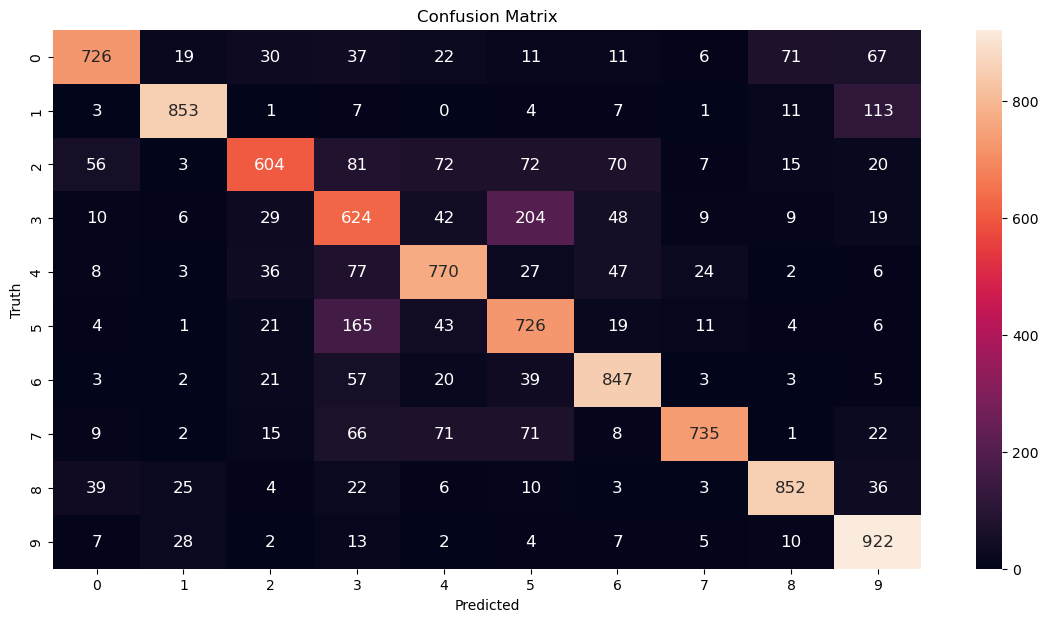

In [54]:
# Convert one-hot encoded true labels into 1D integer labels
# axis=1 specifies finding the argmax along the class probabilities for each sample
y_test_integer_labels = tf.argmax(y_test, axis=1)

# Compute the confusion matrix comparing true labels to predicted labels
# labels: Ground truth integer labels
# predictions: Predicted integer labels obtained earlier
cm = tf.math.confusion_matrix(
    labels=y_test_integer_labels,
    predictions=predicted_labels
)

# Initialize a matplotlib figure with specified dimensions for the heatmap
plt.figure(figsize=(14, 7))

# Import the Seaborn library for advanced data visualization (if not already imported)
import seaborn as sn

# Create a heatmap visualization of the confusion matrix
# annot=True displays the numeric values inside the heatmap cells
# fmt='d' ensures values are formatted as integers
# annot_kws sets the font size of the annotations
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size": 12})

# Set the title and axis labels for the confusion matrix plot
plt.title("Confusion Matrix")  # Title of the figure
plt.xlabel("Predicted")        # Label for the x-axis (predicted classes)
plt.ylabel("Truth")            # Label for the y-axis (true/actual classes)

# Display the generated confusion matrix plot
plt.show()
